In [161]:
# Imports
import matplotlib.pyplot as plt
import numpy as np

if 'Graph' in sys.modules:
    del sys.modules['Graph']
from ModelsImplementations import deffuant, hk, deffuant_history, hk_history
from PlotUtils import plot_evolution_comparison
from Metrics import epsilon_sweep, plot_epsilon_sweep, get_clusters, get_polarization_index, get_theoretical_number_of_clusters, average_epsilon_sweep
from Graph import get_fully_connected, get_small_world, get_scale_free, visualize_graph

# Constant throughout all experiments
N_AGENTS    = 100       # number of agents
STEPS_D     = 20_000    # Deffuant simulation length
STEPS_HK    = 30       # HK simulation length
MU          = 0.5       # Deffuant convergence parameter

OPINION_SEED = 100
INTERACTION_SEED = 101

#TO-DO Check all simulations with different seeds
#TO-DO Run experiments on influence of other parameters

# Opinion Dynamics & Polarization

Ever wondered why people seem to get more extreme over time instead of finding middle ground? This project tries to explore this from a mathematical point of view.

We will model a population of agents each with opinions between $0$ and $1$.  Through simple interaction rules, we will see how consensus, polarization and fragmantation emerge. Will explore how different factors influence the results and the what role recommendation algorithms play in all of this.

### What we'll do

- Implement two mathematical models of opinion dynamics — **Deffuant** and **HK**
- Show how a single parameter controls whether society agrees or fragments
- Test what happens when we have various network structures
- Model the effect of algorithmic bias — what happens when an algorithm keeps showing you people who already agree with you
- Run experiments and measure polarization quantitatively

### Why it matters

What makes this interesting mathematically is that complex collective 
behavior sometimes emerges from extremely simple rules. Even if no agent is trying to polarize society, polarization can still appears as a natural consequence of bounded confidence. This is an example of 
what is called emergent behavior in complex systems.
At the end we will take a step back and look at the bigger picture. We will use the mathematical lens we have built (hopefully) to trace how the way opinions form and spread has changed throughout history - from local village conversations to global algorithmic feeds.

### Assumptions
TO-DO Fromat assumptions
- Throughout the whole project we assume uniform distribution for the initial opinions.

### Limitations
TO-DO Fromat assumptions
- 

### Common variables
- $N = 100$ - number of agents. It is standard in the bounded-confidence literature as it is large enough to show the tendecies we aim to show while still being small enough to not cause experiments take too much time to run.
- Deffuant runs for 30,000 steps
- HK for 40 steps, as it converges much faster
- $\mu = 0.5$throughout - justified in one of the experiments


## The Deffuant Model

Each agent $i$ has an opinion $x_i \in [0, 1]$. At each step, two random agents meet. 
If they are close enough in opinion, then their opinions "move" toward each other:

$$x_i(t+1) = x_i(t) + \mu \cdot (x_j(t) - x_i(t))$$
$$x_j(t+1) = x_j(t) + \mu \cdot (x_i(t) - x_j(t))$$

If their opinions are too far apart, they don't influence each other so nothing happens.

| Symbol | Meaning |
|--------|---------|
| $x_i$ | Opinion of agent $i$, between 0 and 1 |
| $\varepsilon$ | How open-minded agents are - the confidence threshold |
| $\mu$ | How fast they move toward each other (usually 0.5) |



## The Hegselmann-Krause (HK) Model

Same idea as Deffuant. But in this case instead of two people meeting at a time, everyone updates simultaneously. Each agent moves to the average opinion of everyone within their confidence bound:

$$x_i(t+1) = \frac{1}{|B(i,t)|} \sum_{j \in B(i,t)} x_j(t)$$

where $B(i,t)$ is just the set of agents close enough to agent $i$:

$$B(i, t) = \{ j : |x_i(t) - x_j(t)| < \varepsilon \}$$

Think of it as the difference between having one conversation and 
scrolling through your entire social media feed where everyone absorbs 
their whole bubble at once.


## Visualizing Opinion Evolution
Let's see what the models actually look like before we anylize them.
The code below performs simulations for two models with values of $$ \varepsilon $$ varying.
Each line represents one agent's opinion over time. We can see how they either converge into one point, or drift apart into separate clusters.

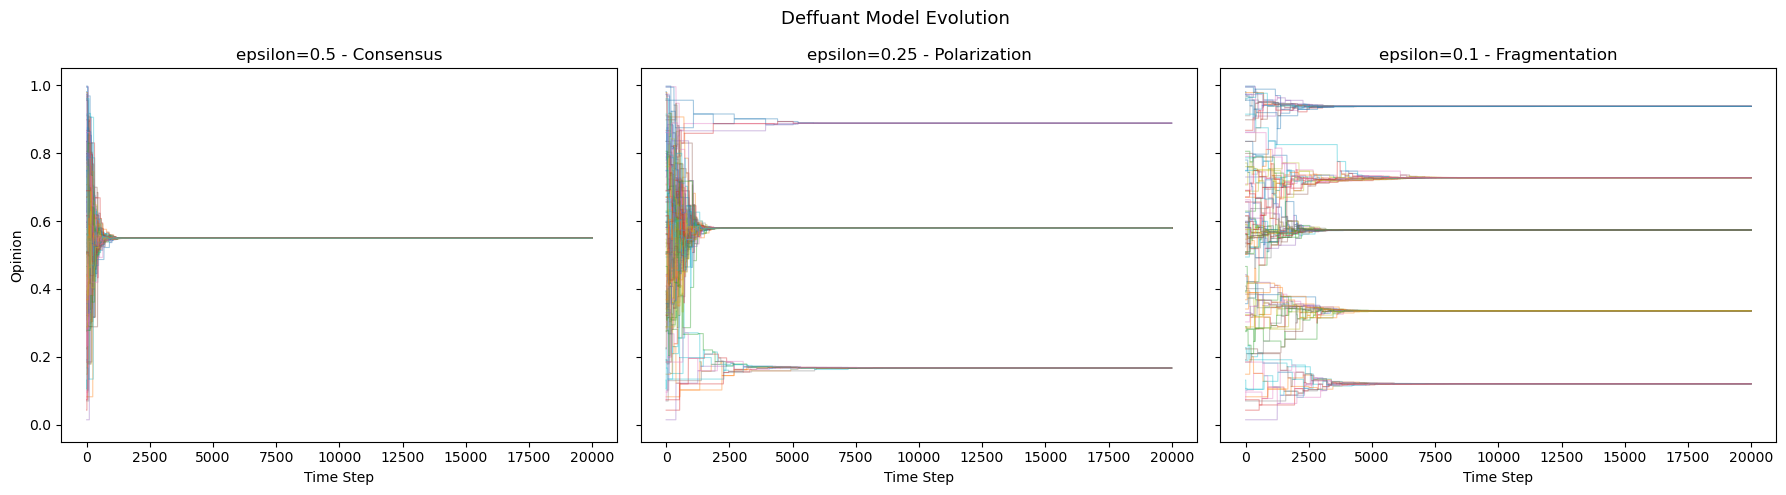

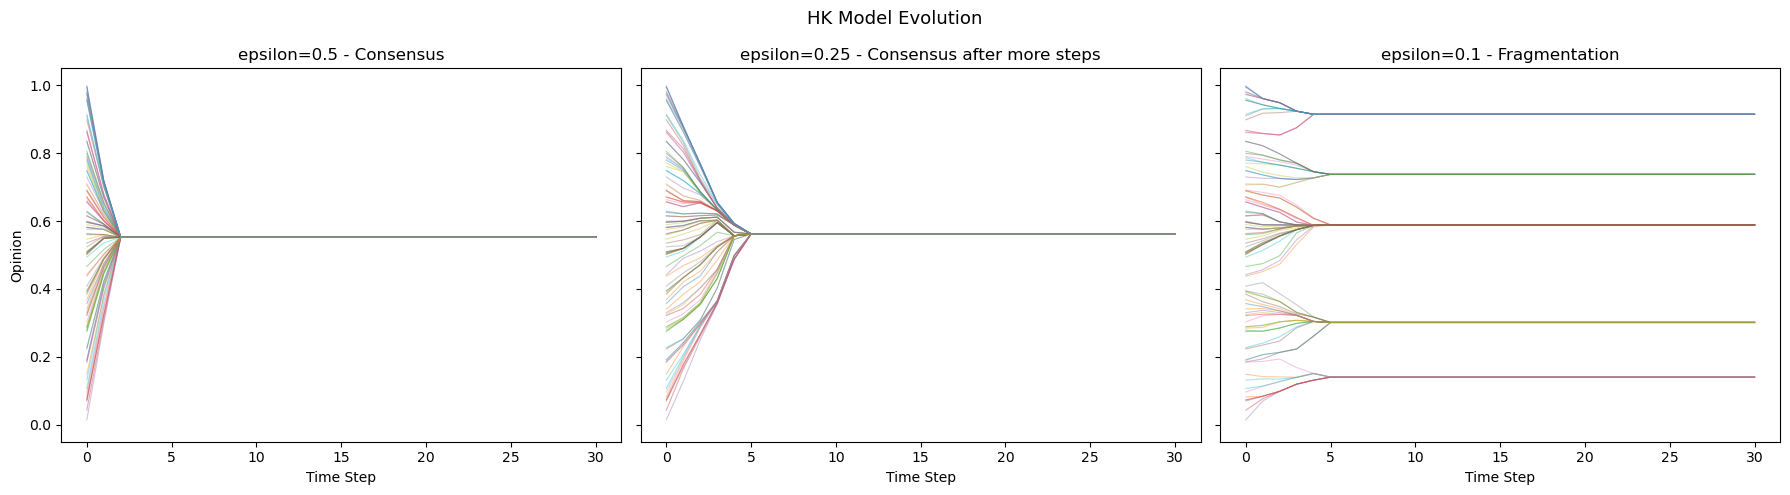

In [138]:


# Run Deffuant
hist_consensus = deffuant_history(N_AGENTS, 0.5,  MU, STEPS_D, opinion_seed=OPINION_SEED, interaction_seed=INTERACTION_SEED)
hist_polar     = deffuant_history(N_AGENTS, 0.25, MU, STEPS_D, opinion_seed=OPINION_SEED, interaction_seed=INTERACTION_SEED)
hist_fragment  = deffuant_history(N_AGENTS, 0.1,  MU, STEPS_D, opinion_seed=OPINION_SEED, interaction_seed=INTERACTION_SEED)

plot_evolution_comparison(
    histories=[hist_consensus, hist_polar, hist_fragment],
    titles=[
        'epsilon=0.5 - Consensus',
        'epsilon=0.25 - Polarization',
        'epsilon=0.1 - Fragmentation'
    ],
    suptitle='Deffuant Model Evolution'
)

# Same for HK
hist_hk_consensus = hk_history(N_AGENTS, 0.5,  STEPS_HK, OPINION_SEED)
hist_hk_polar     = hk_history(N_AGENTS, 0.25, STEPS_HK, OPINION_SEED)
hist_hk_fragment  = hk_history(N_AGENTS, 0.1,  STEPS_HK, OPINION_SEED)
plot_evolution_comparison(
    histories=[hist_hk_consensus, hist_hk_polar, hist_hk_fragment],
    titles=[
        'epsilon=0.5 - Consensus',
        'epsilon=0.25 - Consensus after more steps',
        'epsilon=0.1 - Fragmentation'
    ],
    suptitle='HK Model Evolution'
)


Some things that can be seen from the plot.

In the **Deffuant model** the three regimes are clearly visible:
- $\varepsilon = 0.5$ -> full consensus
- $\varepsilon = 0.25$ -> polarization into two stable camps (will happen in most cases - explained later)
- $\varepsilon = 0.1$ -> fragmentation into several clusters

The **HK model** converges in under significantly less steps across all configurations. This is expected since all $n$ agents update simultaneously rather than two at a time.

There is one very notable difference: at $\varepsilon = 0.25$, Deffuant polarizes while HK reaches consensus. Synchronous updates allow opinion bridges to form before clusters isolate. This result holds regardless of population size and is examined further later.

$$\begin{array}{|c|c|c|}
\hline
\varepsilon & \text{Deffuant} & \text{HK} \\
\hline
0.5 & \text{Consensus} & \text{Consensus} \\
0.25 & \text{Polarization} & \text{Consensus} \\
0.1 & \text{Fragmentation} & \text{Fragmentation} \\
\hline
\end{array}$$

## The Critical Threshold - The Importance Of $\varepsilon$

The confidence threshold $\varepsilon$ is the most important parameter in both of the models. Let's see how actually it affects the outcome.

We can do this by running the simulation many times for different values of $\varepsilon \in [0, 1]$ and recording how many clusters form each time.

The number of final clusters $k$ as a function of $\varepsilon$ follows a pattern:

$$k(\varepsilon) = \left\lfloor \frac{1}{2\varepsilon} \right\rfloor$$

This tells us that the population splits into approximately $\frac{1}{2\varepsilon}$ groups.
For example:
- $\varepsilon = 0.5$ -> $k \approx 1$ (consensus)
- $\varepsilon = 0.25$ -> $k \approx 2$ (polarization)
- $\varepsilon = 0.1$ -> $k \approx 5$ (fragmentation)

**Note:** We only test $\varepsilon \in (0, 0.5]$ because for a uniform 
distribution on $[0,1]$ any $\varepsilon \geq 0.5$ guarantees full consensus. This is true because the two most extreme possible opinions ($0$ and $1$) are always within each other's confidence bound. So above this threshold we will always get consesus as a result even though the number of steps needed to converge is different.

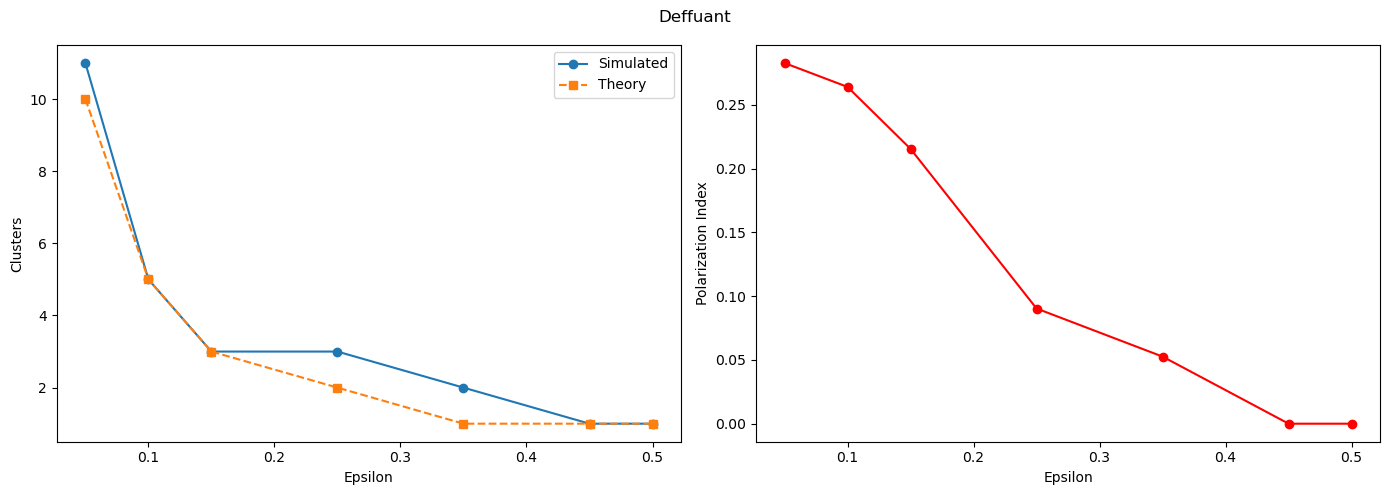

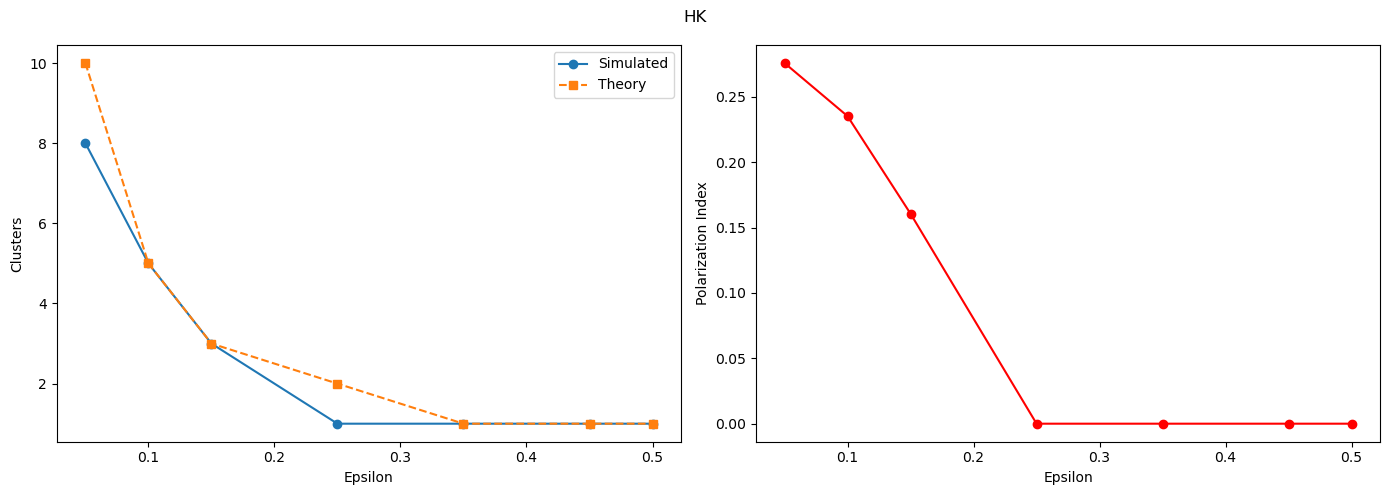

In [139]:
#TO-DO Decide if it is need or only the averaging experiment does the job. DELETE if not needed
seed = 133
n_agents = 50
mu = 0.5
steps_deffuant=20000
steps_hk = 20
epsilon_values = [0.05, 0.1, 0.15, 0.25, 0.35, 0.45, 0.5]

# Generate opinions for each epsilon
opinions_list_d  = [deffuant(N_AGENTS, eps, MU, STEPS_D,
                             opinion_seed=OPINION_SEED,
                             interaction_seed=INTERACTION_SEED)
                    for eps in epsilon_values]

opinions_list_hk = [hk(N_AGENTS, eps, STEPS_HK, opinion_seed=OPINION_SEED)
                    for eps in epsilon_values]

plot_epsilon_sweep(epsilon_sweep(opinions_list_d,  epsilon_values), title='Deffuant')
plot_epsilon_sweep(epsilon_sweep(opinions_list_hk, epsilon_values), title='HK')



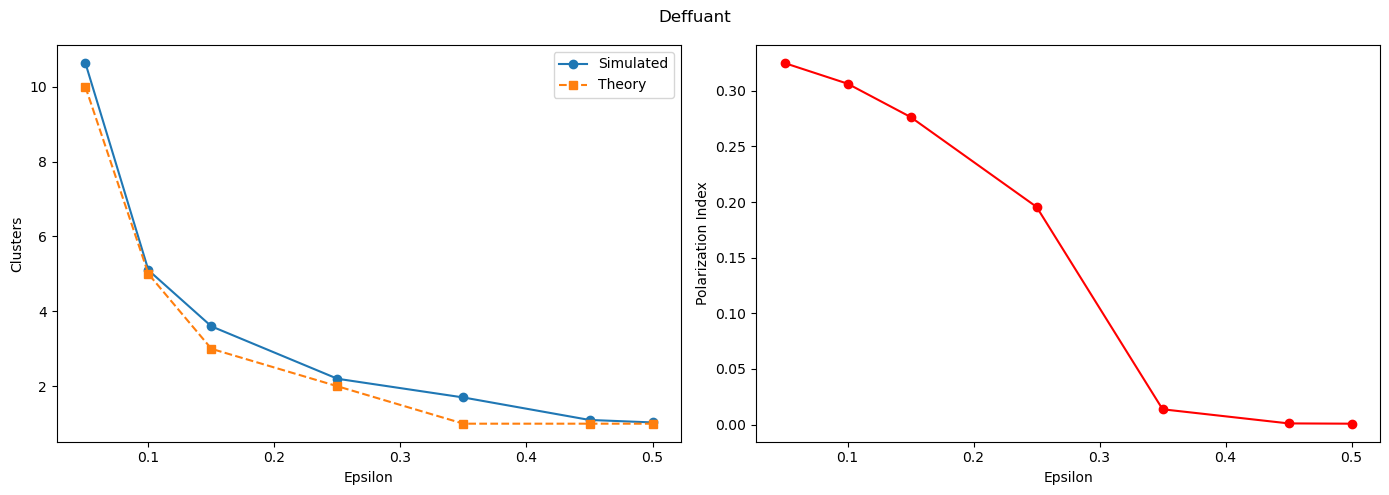

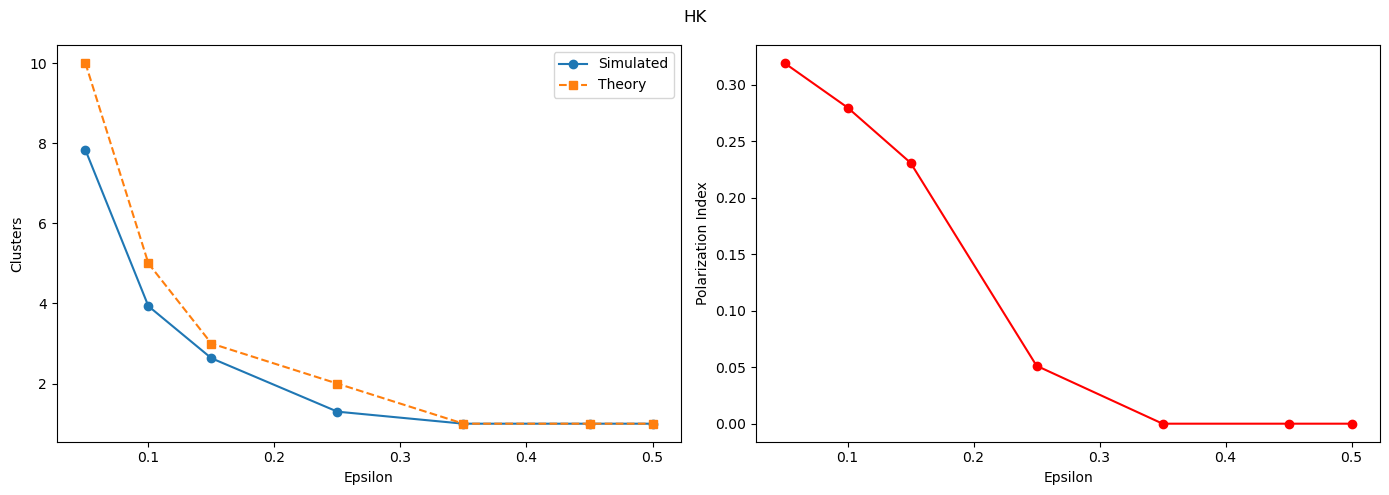

In [155]:
epsilon_values = [0.05, 0.1, 0.15, 0.25, 0.35, 0.45, 0.5]

#TO-DO Document this one
# Allocate beforehand
raw_d  = {eps: [] for eps in epsilon_values}
raw_hk = {eps: [] for eps in epsilon_values}

#Generate opinions
for seed in range(N_RUNS):
    for eps in epsilon_values:
        raw_d[eps].append(deffuant(N_AGENTS, eps, MU, STEPS_D,
                                   opinion_seed=seed,
                                   interaction_seed=seed + 100))
        raw_hk[eps].append(hk(N_AGENTS, eps, STEPS_HK, opinion_seed=seed))

plot_epsilon_sweep(average_epsilon_sweep(epsilon_values, raw_d),  title='Deffuant')
plot_epsilon_sweep(average_epsilon_sweep(epsilon_values, raw_hk), title='HK')

Here is the comparison between the count of clusters from the simulation and the count of clusters we would expect from the formula. SOme small deviation at low epsilon value can be expected as results are more sensitive to the random distribution.

The polarization index drops sharply between $\varepsilon = 0.2$ and $\varepsilon = 0.4$. 
This corresponds to the cluster count dropping from 3 to 1 in the left plot. Fewer clusters means opinions are less spread out so variance drops accordingly. And at $\varepsilon = 0.5$ it reaches 0 as in that case we have a consensus.

We see that the more open-minded the agents, the less the population fragments.

It is interesting that there is actually no closed-form proof. The formula is an
empirical approximation. It is well-supported by simulations, but nobody has formally proved it holds exactly for all cases.
The formal analysis of the topic is given in Lorenz (2007), Section 4.
Full paper available at [arxiv.org/abs/0707.1762](https://arxiv.org/abs/0707.1762)


## Deffuant vs HK - Same Parameters, Different Worlds

Both models use the same $\varepsilon$ and the same initial population, 
yet they can produce different outcomes. Why?

The difference is how and when agents update:

- **Deffuant**
    - asynchronous. Two agents meet and interact, but the rest of the agens are not affected directly by this.
    - stochastic. the random order of pairwise interactions means 
early conversations reinforce local clusters before cross-group bridges can form. 
Once a gap exceeds $\varepsilon$ it is permanent, and since this depends on 
who meets who first, results vary between runs even with identical starting conditions.

- **HK**
    - synchronous. Everyone updates at the same time based on 
  a snapshot of the current state.
    - deterministic.The same initial opinions always produce the same result 
because everyone updates simultaneously and no randomness is involved.


| | Deffuant | HK |
|---|---|---|
| Update type | Asynchronous | Synchronous |
| Randomness | Stochastic | Deterministic |
| Same seed = same result? | No | Yes |
| Convergence speed | Slow  | Fast  |
| Path-dependent? | Yes | No |


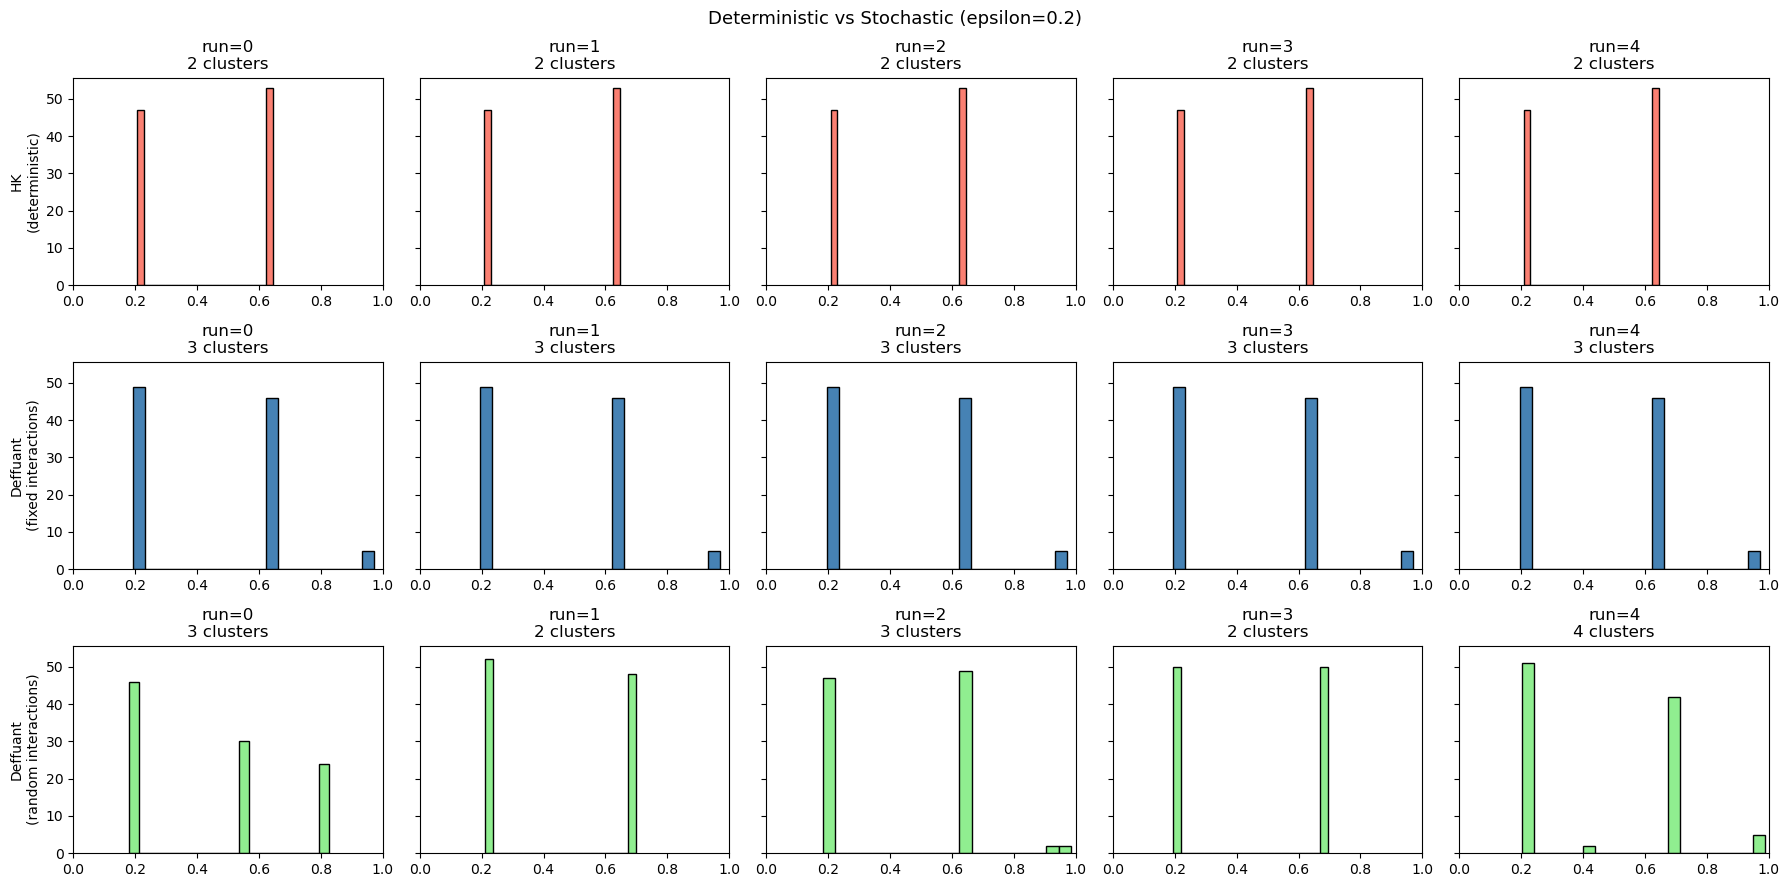

In [35]:

# Same initial opinions for all runs
# Row 1: HK deterministic, should be identical every run
# Row 2: Deffuant fixed interaction order, should be identical every run  
# Row 3: Deffuant random interaction order, should vary between runs

# 5 random numbers
seeds = [122, 24, 38, 411, 5]

# Should be same for all simulations
opinion_seed = 333  

epsilon = 0.2

fig, axes = plt.subplots(3, 5, figsize=(18, 9), sharey=True)
for ax in axes.flat:
    ax.set_xlim(0, 1)
for col, interaction_seed in enumerate(seeds):
    
    # Row 1 - HK, same opinions
    hist_hk = hk(numberOfAgents, epsilon, stepsHk, seed=opinion_seed)
    axes[0][col].hist(hist_hk[-1], bins=20, color='salmon', edgecolor='black')
    axes[0][col].set_title(f'run={col}\n{len(get_clusters(hist_hk[-1], epsilon))} clusters')
    
    # Row 2 - Deffuant, same opinions, same interaction order
    hist_d1 = deffuant(numberOfAgents, epsilon, mu, stepsDeffuant, 
                       opinion_seed=opinion_seed, interaction_seed=opinion_seed)
    axes[1][col].hist(hist_d1[-1], bins=20, color='steelblue', edgecolor='black')
    axes[1][col].set_title(f'run={col}\n{len(get_clusters(hist_d1[-1], epsilon))} clusters')
    
    # Row 3 - Deffuant, same opinions, different interaction order
    hist_d2 = deffuant(numberOfAgents, epsilon, mu, stepsDeffuant,
                       opinion_seed=opinion_seed, interaction_seed=interaction_seed)
    axes[2][col].hist(hist_d2[-1], bins=20, color='lightgreen', edgecolor='black')
    axes[2][col].set_title(f'run={col}\n{len(get_clusters(hist_d2[-1], epsilon))} clusters')

axes[0][0].set_ylabel('HK\n(deterministic)')
axes[1][0].set_ylabel('Deffuant\n(fixed interactions)')
axes[2][0].set_ylabel('Deffuant\n(random interactions)')

plt.suptitle(f'Deterministic vs Stochastic (epsilon={epsilon})', fontsize=13)
plt.tight_layout()
plt.show()

TO-DO Explain the code below and why doint it

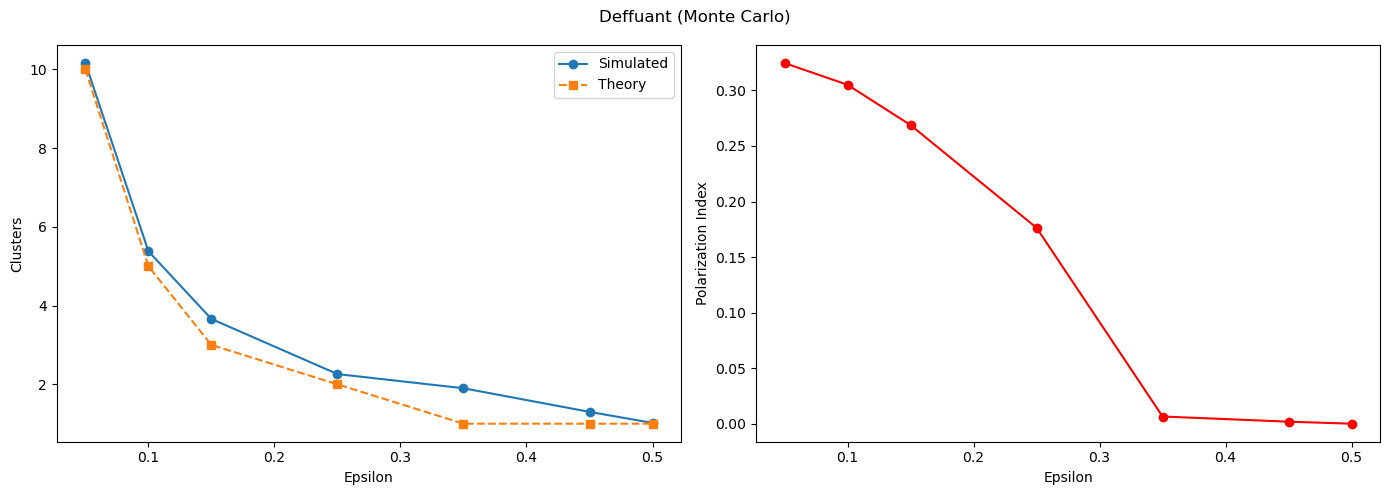

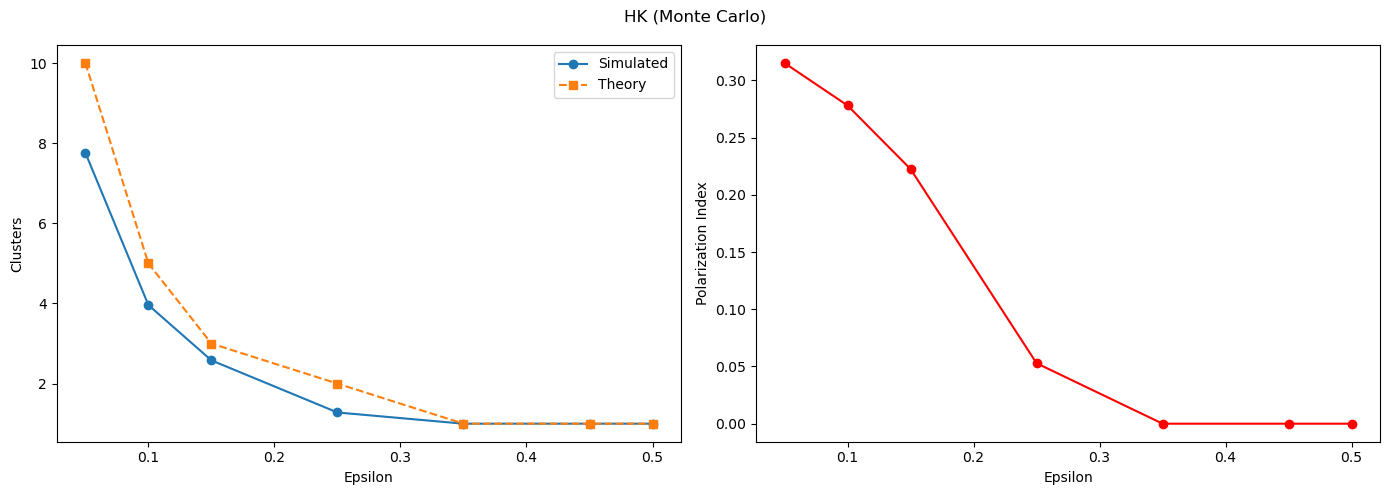

In [104]:
n_runs = 50

#TO-DO Refactor - check for mistakes, check seeds, wehre to use random where to be static
# For each epsilon, run n_runs times and average the results
results_d  = []
results_hk = []
seed = 218
n_agents = 200
mu = 0.5
steps_deffuant=20000
steps_hk = 20
epsilon_values = [0.05, 0.1, 0.15, 0.25, 0.35, 0.45, 0.5]
for eps in epsilon_values:
    runs_d  = [deffuant(n_agents, eps, mu, steps_deffuant,
                        opinion_seed=run*seed, interaction_seed=run)
               for run in range(n_runs)]
    runs_hk = [hk(numberOfAgents, eps, steps_hk, opinion_seed=run)
               for run in range(n_runs)]
    
    results_d.append([
        eps,
        sum(len(get_clusters(r, eps)) for r in runs_d)  / n_runs,
        sum(get_polarization_index(r) for r in runs_d)  / n_runs,
        get_theoretical_number_of_clusters(eps)
    ])
    results_hk.append([
        eps,
        sum(len(get_clusters(r, eps)) for r in runs_hk) / n_runs,
        sum(get_polarization_index(r) for r in runs_hk) / n_runs,
        get_theoretical_number_of_clusters(eps)
    ])

plot_epsilon_sweep(results_d,  title='Deffuant (Monte Carlo)')
plot_epsilon_sweep(results_hk, title='HK (Monte Carlo)')

In [ ]:
epsilon_values = [0.05, 0.1, 0.15, 0.25, 0.35, 0.45, 0.5]

# Allocate beforehand
raw_d  = {eps: [] for eps in epsilon_values}
raw_hk = {eps: [] for eps in epsilon_values}

#Generate opinions
for seed in range(N_RUNS):
    for eps in epsilon_values:
        raw_d[eps].append(deffuant(N_AGENTS, eps, MU, STEPS_D,
                                   opinion_seed=seed,
                                   interaction_seed=seed + 100))
        raw_hk[eps].append(hk(N_AGENTS, eps, STEPS_HK, opinion_seed=seed))

plot_epsilon_sweep(average_epsilon_sweep(epsilon_values, raw_d),  title='Deffuant')
plot_epsilon_sweep(average_epsilon_sweep(epsilon_values, raw_hk), title='HK')


Another effect of these differences between the models is in the exact number of clusters of opinions.
Both models broadly confirm the theoretical prediction 
$k(\varepsilon) \approx \lfloor \frac{1}{2\varepsilon} \rfloor$.
But still we see notable difference.

**Deffuant** follows the theory closely at mid-range epsilon values but at small epsilon produces more clusters than predicted. 
This is expected in some way: at very small confidence bounds, the stochastic interaction 
order means some agents never interact with the right neighbors, 
leaving more isolated clusters behind.

**HK** undershoots the theory at small epsilon. It produces fewer clusters 
than predicted. Simultaneous updates allow agents to influence each other 
more efficiently so clusters that Deffuant would leave separate actually merge.

Both polarization curves drop sharply between $\varepsilon = 0.2$ and 
$\varepsilon = 0.4$. This corresponds to the cluster count dropping 
from 3 to 1.

## Convergence

Both models are guaranteed to converge. How do we know this for certain? ANd why does it matter?

The following proof is adapted from Hegselmann & Krause (2002), Section 3 
*(full paper: [jasss.soc.surrey.ac.uk/5/3/2.html](http://jasss.soc.surrey.ac.uk/5/3/2.html))*.
The details are outside of the scope of this project and it is included for completeness and is taken from  Hegselmann & Krause (2002).

---

#### HK Convergence Proof

Claim: The HK model always converges to a fixed point in finite time.

**Step 1. The global mean is conserved.**

At each step, agent $i$ moves to the average of its confidence set $B(i,t)$:

$$x_i(t+1) = \frac{1}{|B(i,t)|} \sum_{j \in B(i,t)} x_j(t)$$

The interaction is symmetric. If $j \in B(i,t)$ then $i \in B(j,t)$ Thus 
the global mean is preserved at every step:

$$\bar{x}(t+1) = \bar{x}(t) = \bar{x}$$

**Step 2. The total variance is non-increasing.**

Define the total variance at time $t$:

$$V(t) = \sum_{i=1}^{n} \left( x_i(t) - \bar{x} \right)^2$$

Since each agent moves to a local average within its confidence set, 
by the convexity of the squared function:

$$\left( x_i(t+1) - \bar{x} \right)^2 \leq \frac{1}{|B(i,t)|} \sum_{j \in B(i,t)} \left( x_j(t) - \bar{x} \right)^2$$

Summing over all agents:

$$V(t+1) \leq V(t)$$

**Step 3. The system reaches a fixed point in finite time.**

$V(t)$ is non-increasing and bounded below by $0$, so it must converge. 
The confidence sets $B(i,t)$ can only shrink or stay the same over time - 
once two agents drift apart beyond $\varepsilon$ they never interact again. 
Since there are finitely many agents, the system must eventually reach 
a state where no agent moves:

$$x_i(t+1) = x_i(t) \quad \forall i \quad \blacksquare$$

At this fixed point, every agent equals the average of its confidence set:

$$x_i^* = \frac{1}{|B(i)|} \sum_{j \in B(i)} x_j^* \quad \forall i$$

---

#### Deffuant Convergence

The formal proof follows a similar variance argument and is given in 
Deffuant et al. (2000). The intuition is simple - agents only move 
toward each other, never apart, so variance can only decrease.
The system stops when no two agents are within $\varepsilon$ of each other:

$$|x_i^* - x_j^*| \geq \varepsilon \quad \forall i \neq j \text{ in different clusters} \quad \blacksquare$$

---

#### Why This Matters

This guarantees that the final simulation state is always meaningful, not just a snapshot that will change after more steps.

## The Role of μ - Does it matter for the final number of clusters

When two agents$i$ and $j$ interact successfully, their opinions update as:

$$o_i \leftarrow o_i + \mu (o_j - o_i), \qquad o_j \leftarrow o_j + \mu (o_i - o_j)$$

At $\mu = 0.5$ agents meet exactly halfway. At 
$\mu = 0.1$ they take only a small step toward each other. Since μ only scales the step size without changing who can interact, the final cluster structure should be independent of μ.
We can see this from the next experiment.

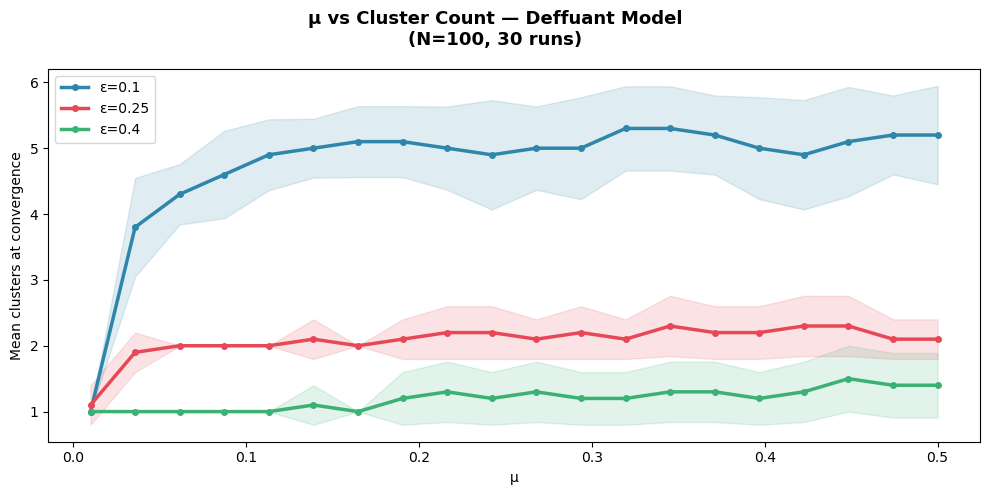

In [147]:
mu_vals        = np.linspace(0.01, 0.5, 20)
epsilon_values = [0.1, 0.25, 0.4]
colors         = ['#2E86AB', '#E84855', '#3BB273']

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle(f'μ vs Cluster Count — Deffuant Model\n'
             f'(N={N_AGENTS}, {N_RUNS} runs)', fontsize=13, fontweight='bold')

for eps, color in zip(epsilon_values, colors):
    means, stds = [], []

    for mu in mu_vals:
        clusters = [len(get_clusters(
                        deffuant(N_AGENTS, eps, mu, STEPS_D,
                                 opinion_seed=seed,
                                 interaction_seed=seed + 100), eps))
                    for seed in range(10)]
        means.append(np.mean(clusters))
        stds.append(np.std(clusters))

    means, stds = np.array(means), np.array(stds)
    ax.plot(mu_vals, means, color=color, lw=2.5,
            marker='o', ms=4, label=f'ε={eps}')
    ax.fill_between(mu_vals, means - stds, means + stds,
                    color=color, alpha=0.15)

ax.set_xlabel('μ')
ax.set_ylabel('Mean clusters at convergence')
ax.legend()
plt.tight_layout()
plt.show()

The results confirm the theoretical prediction on both rows of the figure.

**Convergence speed (top row):** At $\mu = 0.1$ agents converge slowly over ~30,000
steps; at $\mu = 0.5$ the same process completes within ~3,000 steps. The shape
differs too — small μ produces gradual funnelling, large μ produces sharp jumps.

**Final cluster structure (bottom row):** All four values produce an identical cluster
distribution — mean $1.1 \pm 0.2$ in all cases. μ has no effect on the final state.

This justifies fixing $\mu = 0.5$ in all subsequent experiments — any other value
produces identical final opinions while only slowing down the simulation.

## Adding Network Structure

TO-DO Explore how the results change when the structure of connections is different. Use graphs to model this, find how to represent it visually. And how to implement it

So far we have assumed a **fully connected** network. This means that every agent can interact with
every other agent. TWe used is as baseline, but its interesting to see what happens in circumstances that are closer to the real world. In reality interactions are constrained by social circles, geography,
algorithmic curation and many other factors. 

Let's model the social network as an undirected graph $G = (V, E)$.
$V$ represents our agents.
$E$ represent possible interactions.
We will examine 3 types of topolgies:

### Fully Connected
$|E| = \frac{N(N-1)}{2}$
Every agent is connected to every other agent. Like a town hall where every citizen can speak to every other. Unrealistic as $N$ grows.

### Small-World (Watts-Strogatz)
We form then in the following way:
1. Agents start connected to their $k$ nearest neighbours on a ring.
2. Each edge isrewired with probability $p$.
WE try to model real offline social networks. Local communities that are connected by long-range bridges. Even a small $p$ dramatically reduces average path length. We will examine the improtance of the $p$ parameter later.

### Scale-Free (Barabási-Albert)
In this case new nodes attach preferentially to already well-connected nodes.
This produces a power-law degree distribution $P(k) \sim k^{-\gamma}$. Which means that a small number
of **hubs** (think Twitter influencers) dominate connectivity, while a long tail of
peripheral nodes remain isolated. These peripherals are the most vulnerable to permanent opinion fragmentation. TO-DO check if the experiments on this can be fit in the project

---

The three topologies have different effect on the forming of opinions. A key insight is
that network structure effectively limits opinion spread. Even if two agents are
within each other's confidence bound, they can only interact if the network connects
them. In this sense, being isolated is similar to being intolerant.


In the next cell we generate an example for each of the three topologies. In this way it will be easier to build some intuition about them.

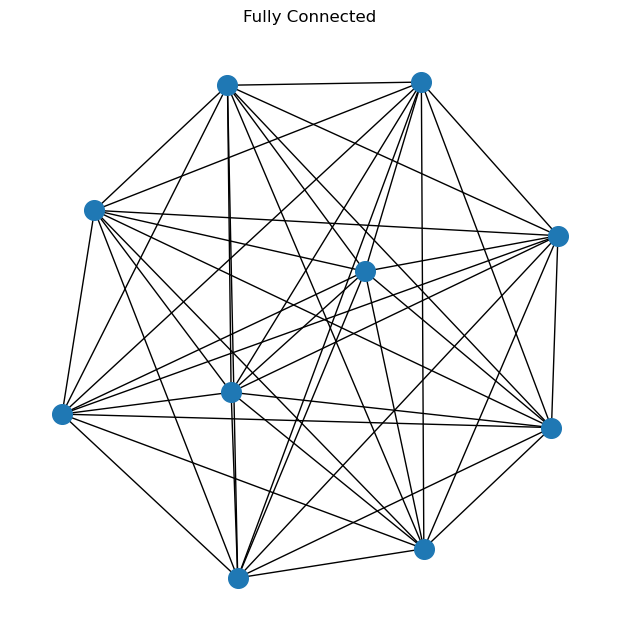

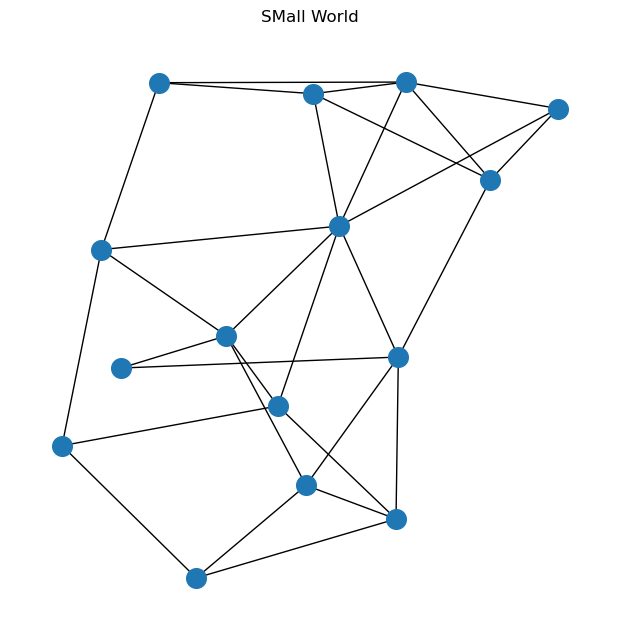

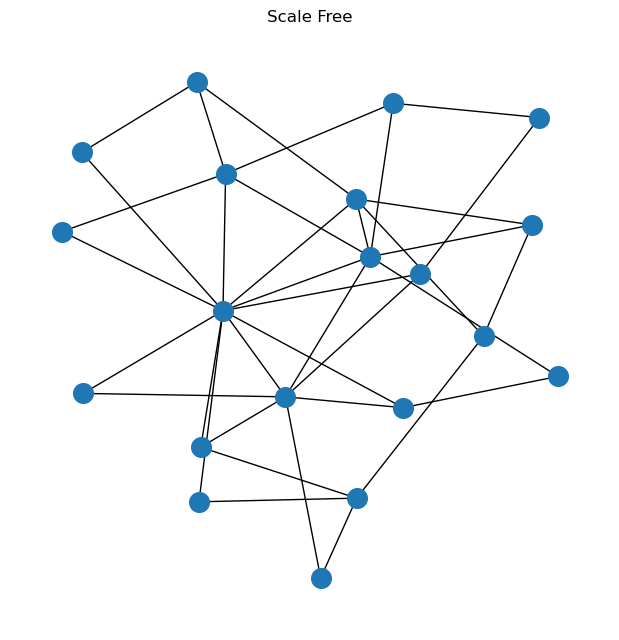

In [173]:
# TO-DO decide if using nx or write more specific visualization function if time is enough...
import networkx as nx
import matplotlib.pyplot as plt

G1 =  get_fully_connected(10)
G2 =  get_small_world(15, p=0.3)
G3 = get_scale_free(20, m=2)

def visualize_graph_nx(G, title="Graph"):
    H = nx.Graph()

    n = G.n_nodes

    # add edges
    for i in range(n):
        for j in range(i+1, n):
            if G.A[i][j] == 1:
                H.add_edge(i, j)

    pos = nx.spring_layout(H, seed=42)

    plt.figure(figsize=(6,6))
    nx.draw(H, pos, node_size=200)
    plt.title(title)
    plt.show()

visualize_graph_nx(G1, "Fully Connected")
visualize_graph_nx(G2, "SMall World")
visualize_graph_nx(G3, "Scale Free")

## The Echo Chamber - How Algorithmic Bias Affects Opinions

TO-DO Try to simulate algorithmic bias and see how this influences the results. In some way to simulate the influence of social media recommendation algorithms

## Applications
TO-DO Make sure that applications are shown and explaiend, its important, Delete the section if this task is done in other sections. CHECK. 

## Conclusions
TO-DO Fill with conclusions, obviously

## References
TO-DO Fill references along the way. Maybe check proper format before final commit.

- Deffuant, G., Neau, D., Amblard, F., & Weisbuch, G. (2000). *Mixing beliefs among interacting agents.* Advances in Complex Systems, 3(1-4), 87-98. https://www.researchgate.net/publication/235737446_Mixing_Beliefs_Among_Interacting_Agents
- Hegselmann, R., & Krause, U. (2002). *Opinion dynamics and bounded confidence: models, analysis and simulation.* Journal of Artificial Societies and Social Simulation, 5(3).  https://www.jasss.org/5/3/2.html
- Lorenz, J. (2007). *Continuous opinion dynamics under bounded confidence: 
  A survey.* International Journal of Modern Physics C, 18(12), 1819-1838.
  Available at: https://arxiv.org/abs/physics/0607212
- Watts-Strogatz: Watts, D.J. & Strogatz, S.H. (1998). Collective dynamics of 'small-world' networks. Nature, 393, 440–442.
- Barabási-Albert: Barabási, A.L. & Albert, R. (1999). Emergence of scaling in random networks. Science, 286, 509–512.  https://arxiv.org/abs/cond-mat/9910332